In [1]:
import torch  # PyTorch深度学习框架
import os
os.environ['HF_HOME'] = "../"
os.environ['HF_HUB_CACHE'] = ".cache/huggingface"
from transformers import (
    TrainingArguments,  # Transformers训练参数类
    Trainer,  # Transformers训练器
    HfArgumentParser,  # HuggingFace参数解析器
)
from utils import load_model, load_processor  # 导入自定义的模型和处理器加载函数
from train import VQADatasetLoader, load_mm_data
from inference_vl_model import VLInferenceDataset

/root/autodl-tmp/Qwen3-SmVL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/root/autodl-tmp/Qwen3-SmVL/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### CVLUE dataset

In [3]:
train_data = "./data/CVLUE/annotation/CVLUE_train_annotation/train_VQA.json"

loader = VQADatasetLoader(train_data, image_base_path="data/CVLUE")
cvlue_data_train = loader.load(sample_count=None, seed=42)

In [4]:
cvlue_data_train

Dataset({
    features: ['images', 'question_id', 'texts'],
    num_rows: 43086
})

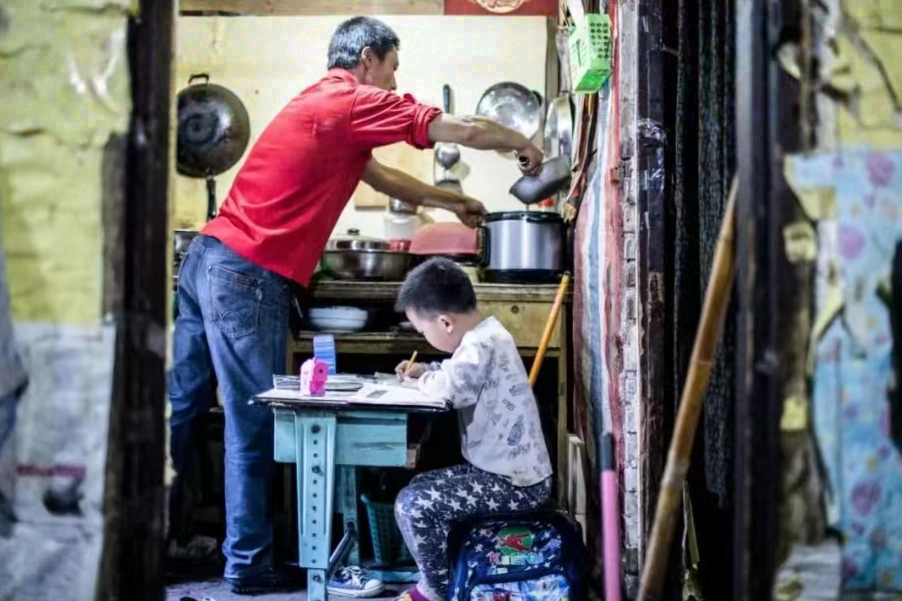

In [19]:
cvlue_data_train["images"][0]

### Benchmark data

In [11]:
JSONL_PATH = "data/AlignMMBench/metadata.jsonl"  # Path to your input JSONL file
IMAGE_ROOT = "data/AlignMMBench/"  # Root directory for images (None = same as JSONL directory)


alignmmbench_data = VLInferenceDataset(JSONL_PATH, IMAGE_ROOT)

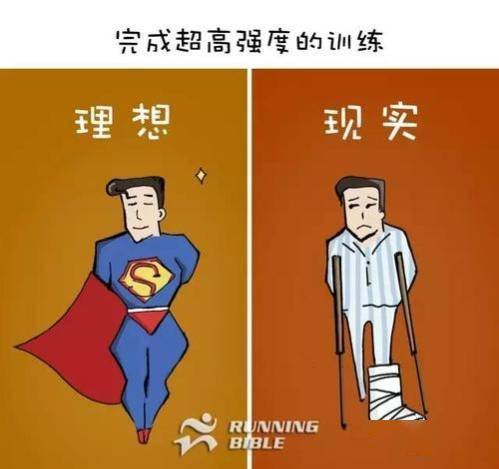

In [12]:
alignmmbench_data[0]["image"].show()

### Load processor

In [12]:
qwen_smvl_processor = load_processor()

正在加载SmolVLM2处理器...
正在加载Qwen3分词器...
正在配置处理器...


In [6]:
qwen_smvl_processor

SmolVLMProcessor:
- image_processor: SmolVLMImageProcessor {
  "do_convert_rgb": true,
  "do_image_splitting": true,
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "SmolVLMImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "max_image_size": {
    "longest_edge": 512
  },
  "processor_class": "SmolVLMProcessor",
  "resample": 1,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 2048
  },
  "video_sampling": {
    "fps": 1,
    "max_frames": 64,
    "video_size": {
      "longest_edge": 512
    }
  }
}

- tokenizer: Qwen2TokenizerFast(name_or_path='model/Qwen3-0.6B', vocab_size=151643, model_max_length=131072, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>', 'additional_special_tokens': ['<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_

In [16]:
qwen_smvl_processor.__dict__

{'fake_image_token': '<vision_start>',
 'image_token': '<|image_pad|>',
 'image_token_id': 151655,
 'end_of_utterance_token': '<im_end>',
 'global_image_token': '<|vision_pad|>',
 'image_seq_len': 64,
 'video_token': '<|video_pad|>',
 'chat_template': '{%- if tools %}\n    {{- \'<|im_start|>system\\n\' }}\n    {%- if messages[0].role == \'system\' %}\n        {{- messages[0].content + \'\\n\\n\' }}\n    {%- endif %}\n    {{- "# Tools\\n\\nYou may call one or more functions to assist with the user query.\\n\\nYou are provided with function signatures within <tools></tools> XML tags:\\n<tools>" }}\n    {%- for tool in tools %}\n        {{- "\\n" }}\n        {{- tool | tojson }}\n    {%- endfor %}\n    {{- "\\n</tools>\\n\\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\\n<tool_call>\\n{\\"name\\": <function-name>, \\"arguments\\": <args-json-object>}\\n</tool_call><|im_end|>\\n" }}\n{%- else %}\n    {%- if messages[0

In [22]:
qwen_smvl_processor.tokenizer

Qwen2TokenizerFast(name_or_path='model/Qwen3-0.6B', vocab_size=151643, model_max_length=131072, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>', 'additional_special_tokens': ['<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>']}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151646: AddedToken("<|object_ref_start|>", rstrip=False, lstrip=False, single_word=False, normalize

In [7]:
image_processor = qwen_smvl_processor

processed_im = image_processor(cvlue_data_train["images"][0], return_tensors="pt").to(dtype=torch.bfloat16)
processed_im["pixel_values"].shape

torch.Size([1, 13, 3, 512, 512])

### SmolVLM processor

In [17]:
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    AutoTokenizer,
    AutoModelForCausalLM,
)

smolvlm2_processor = AutoProcessor.from_pretrained(
    "model/SmolVLM2-256M-Video-Instruct"
)

In [21]:
smolvlm2_processor.tokenizer

GPT2TokenizerFast(name_or_path='model/SmolVLM2-256M-Video-Instruct', vocab_size=49152, model_max_length=8192, is_fast=True, padding_side='right', truncation_side='left', special_tokens={'bos_token': '<|im_start|>', 'eos_token': '<end_of_utterance>', 'unk_token': '<|endoftext|>', 'pad_token': '<|im_end|>', 'additional_special_tokens': ['<fake_token_around_image>', '<image>', '<end_of_utterance>'], 'end_of_utterance_token': '<end_of_utterance>', 'fake_image_token': '<fake_token_around_image>', 'global_image_token': '<global-img>', 'image_token': '<image>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<repo_name>", rstrip=False, lst

### Use vision model and connetor to process image directly

In [3]:
smolvlm2_qwen3 = load_model()

正在加载SmolVLM2视觉-语言模型...
正在加载Qwen3语言模型...
正在构建连接器配置...
正在创建新的连接器...
正在替换语言模型组件...
正在更新模型配置...
模型构建完成！


In [4]:
smolvlm2_qwen3

SmolVLMForConditionalGeneration(
  (model): SmolVLMModel(
    (vision_model): SmolVLMVisionTransformer(
      (embeddings): SmolVLMVisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): SmolVLMEncoder(
        (layers): ModuleList(
          (0-11): 12 x SmolVLMEncoderLayer(
            (self_attn): SmolVLMVisionAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): SmolVLMVisionMLP(
              (activation_fn): PytorchGELUTanh()
              (fc1): Linear(in_features=768, out_

In [9]:
smolvlm2_qwen3.model.text_model.__dict__

{'training': False,
 '_parameters': {},
 '_buffers': {},
 '_non_persistent_buffers_set': set(),
 '_backward_pre_hooks': OrderedDict(),
 '_backward_hooks': OrderedDict(),
 '_is_full_backward_hook': None,
 '_forward_hooks': OrderedDict(),
 '_forward_hooks_with_kwargs': OrderedDict(),
 '_forward_hooks_always_called': OrderedDict(),
 '_forward_pre_hooks': OrderedDict(),
 '_forward_pre_hooks_with_kwargs': OrderedDict(),
 '_state_dict_hooks': OrderedDict(),
 '_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_post_hooks': OrderedDict(),
 '_modules': {'embed_tokens': Embedding(151936, 1024),
  'layers': ModuleList(
    (0-27): 28 x Qwen3DecoderLayer(
      (self_attn): Qwen3Attention(
        (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
        (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (o_proj): Linear(in_features=2

In [10]:
smolvlm2_qwen3.model.text_model.embed_tokens

Embedding(151936, 1024)

In [9]:
vision_model = smolvlm2_qwen3.model.vision_model
vision_model

SmolVLMVisionTransformer(
  (embeddings): SmolVLMVisionEmbeddings(
    (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
    (position_embedding): Embedding(1024, 768)
  )
  (encoder): SmolVLMEncoder(
    (layers): ModuleList(
      (0-11): 12 x SmolVLMEncoderLayer(
        (self_attn): SmolVLMVisionAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): SmolVLMVisionMLP(
          (activation_fn): PytorchGELUTanh()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        )
        (layer_norm2): LayerNorm((768,)

In [10]:
vit_lm_connector = smolvlm2_qwen3.model.connector
vit_lm_connector

SmolVLMConnector(
  (modality_projection): SmolVLMSimpleMLP(
    (proj): Linear(in_features=12288, out_features=1024, bias=False)
  )
)

In [29]:
processed_im

{'pixel_values': tensor([[[[[ 0.1846,  0.1846,  0.1689,  ..., -0.0588, -0.0510, -0.0432],
           [ 0.1768,  0.1768,  0.1689,  ..., -0.0588, -0.0510, -0.0432],
           [ 0.1689,  0.1689,  0.1611,  ..., -0.0510, -0.0432, -0.0354],
           ...,
           [ 0.0039,  0.0118,  0.0354,  ...,  0.9297,  0.8594,  0.7656],
           [ 0.0118,  0.0118,  0.0354,  ...,  0.8828,  0.7969,  0.6875],
           [ 0.0197,  0.0197,  0.0354,  ...,  0.8281,  0.7188,  0.6094]],

          [[ 0.2236,  0.2236,  0.2236,  ..., -0.1611, -0.1611, -0.1455],
           [ 0.2236,  0.2236,  0.2236,  ..., -0.1611, -0.1611, -0.1455],
           [ 0.2158,  0.2158,  0.2158,  ..., -0.1611, -0.1611, -0.1533],
           ...,
           [ 0.0981,  0.1138,  0.1455,  ...,  0.4512,  0.3105,  0.1299],
           [ 0.0981,  0.1138,  0.1455,  ...,  0.3574,  0.1924,  0.0039],
           [ 0.1060,  0.1216,  0.1377,  ...,  0.2559,  0.0825, -0.0981]],

          [[-0.0197, -0.0197, -0.0197,  ..., -0.4355, -0.4277, -0.4199]

In [13]:
vision_model(processed_im["pixel_values"])

ValueError: too many values to unpack (expected 4)

### Use hook function

#### AlignMM distribution

In [2]:
from inference_vl_model import run_inference

MODEL_NAME_OR_PATH = "model/freeze_llm_vlm_cvlue_fulldata"  # Change this to your model

# Dataset configuration
JSONL_PATH = "data/AlignMMBench/metadata.jsonl"  # Path to your input JSONL file
IMAGE_ROOT = "data/AlignMMBench/"  # Root directory for images (None = same as JSONL directory)
OUTPUT_PATH = "inference/dummy.jsonl"  # Output file path

# Inference configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_NEW_TOKENS = 512
TEMPERATURE = 0.7
TOP_P = 0.9
BATCH_SIZE = 8  # Adjust based on your GPU memory (1, 2, 4, 8, 16, etc.)

# ===== RUN INFERENCE =====
run_inference(
    checkpoint_path=MODEL_NAME_OR_PATH,
    jsonl_path=JSONL_PATH,
    output_path=OUTPUT_PATH,
    image_root=IMAGE_ROOT,
    batch_size=BATCH_SIZE,
    max_new_tokens=MAX_NEW_TOKENS,
    temperature=TEMPERATURE,
    top_p=TOP_P,
    device=DEVICE
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading dataset from data/AlignMMBench/metadata.jsonl...
Loaded 16 samples
正在加载训练后的模型: model/freeze_llm_vlm_cvlue_fulldata
正在加载SmolVLM2视觉-语言模型...
正在加载Qwen3语言模型...
正在构建连接器配置...
正在创建新的连接器...
正在替换语言模型组件...
正在更新模型配置...
模型构建完成！
正在加载SmolVLM2处理器...
正在加载Qwen3分词器...
正在配置处理器...
正在加载safetensors权重...
✅ 权重加载成功

Running inference on 16 samples with batch_size=8 for model model/freeze_llm_vlm_cvlue_fulldata...
GPU = NVIDIA GeForce RTX 5090. Max memory = 31.357 GB.
1.689 GB of memory reserved.
开始推理...


Inference:   0%|          | 0/2 [00:00<?, ?it/s]

✓ Logged to CSV: ./temp/image_token_length.csv

[Hook Triggered] Connector layer executed! (Call #1)
Output type: <class 'torch.Tensor'>
Hook module: SmolVLMConnector(
  (modality_projection): SmolVLMSimpleMLP(
    (proj): Linear(in_features=12288, out_features=1024, bias=False)
  )
)
Input: torch.Size([120, 1024, 768])
Output shape: torch.Size([120, 64, 1024])
Sequence length after connector: 64


Inference:  50%|█████     | 1/2 [00:12<00:12, 12.30s/it]

✓ Logged to CSV: ./temp/image_token_length.csv

[Hook Triggered] Connector layer executed! (Call #2)
Output type: <class 'torch.Tensor'>
Hook module: SmolVLMConnector(
  (modality_projection): SmolVLMSimpleMLP(
    (proj): Linear(in_features=12288, out_features=1024, bias=False)
  )
)
Input: torch.Size([88, 1024, 768])
Output shape: torch.Size([88, 64, 1024])
Sequence length after connector: 64


Inference: 100%|██████████| 2/2 [00:23<00:00, 11.64s/it]

推理完成...
23.2858 seconds used for inference.
0.39 minutes used for inference.
Peak reserved memory = 21.104 GB.
Peak reserved memory for inference = 19.415 GB.
Peak reserved memory % of max memory = 67.302 %.
Peak reserved memory for inference % of max memory = 61.916 %.

Inference complete! Results saved to inference/dummy.jsonl
Total samples processed: 16


#### Cauldron distribution

In [2]:
from inference_vl_model import run_inference
from train import load_mm_data

MODEL_NAME_OR_PATH = "model/freeze_llm_vlm_cvlue_fulldata"  # Change this to your model

# Dataset configuration
IMAGE_ROOT = "data/AlignMMBench/"  # Root directory for images (None = same as JSONL directory)
OUTPUT_PATH = "inference/dummy.jsonl"  # Output file path
CSV_PATH = "temp/cauldron_image_token_distribution.csv"

# Inference configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_NEW_TOKENS = 512
TEMPERATURE = 0.7
TOP_P = 0.9
BATCH_SIZE = 16  # Adjust based on your GPU memory (1, 2, 4, 8, 16, etc.)

raw_data_train = load_mm_data(select_data="all", seed=42)["train"].select(range(8))

# ===== RUN INFERENCE =====
run_inference(
    checkpoint_path=MODEL_NAME_OR_PATH,
    data = raw_data_train,
    output_path=OUTPUT_PATH,
    csv_path=CSV_PATH,
    image_root=IMAGE_ROOT,
    batch_size=BATCH_SIZE,
    max_new_tokens=MAX_NEW_TOKENS,
    temperature=TEMPERATURE,
    top_p=TOP_P,
    device=DEVICE
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded 8 samples
正在加载训练后的模型: model/freeze_llm_vlm_cvlue_fulldata
正在加载SmolVLM2视觉-语言模型...
正在加载Qwen3语言模型...
正在构建连接器配置...
正在创建新的连接器...
正在替换语言模型组件...
正在更新模型配置...
模型构建完成！
正在加载SmolVLM2处理器...
正在加载Qwen3分词器...
正在配置处理器...
正在加载safetensors权重...
✅ 权重加载成功

Running inference on 8 samples with batch_size=16 for model model/freeze_llm_vlm_cvlue_fulldata...
GPU = NVIDIA GeForce RTX 5090. Max memory = 31.357 GB.
1.689 GB of memory reserved.
开始推理...


Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Batch image row shape before model processor:  8
total number of images in batch: 8
Batch image tensor shape after model processor: torch.Size([8, 17, 3, 512, 512])
Batch text tensor shape after model processor: torch.Size([8, 4498])
✓ Logged to CSV: temp/cauldron_image_token_distribution.csv

[Hook Triggered] Connector layer executed! (Call #1)
Output type: <class 'torch.Tensor'>
Hook module: SmolVLMConnector(
  (modality_projection): SmolVLMSimpleMLP(
    (proj): Linear(in_features=12288, out_features=1024, bias=False)
  )
)
Input: torch.Size([120, 1024, 768])
Output shape: torch.Size([120, 64, 1024])
Sequence length after connector: 64


Inference: 100%|██████████| 1/1 [00:20<00:00, 20.02s/it]

推理完成...
20.0201 seconds used for inference.
0.33 minutes used for inference.
Peak reserved memory = 21.221 GB.
Peak reserved memory for inference = 19.532 GB.
Peak reserved memory % of max memory = 67.675 %.
Peak reserved memory for inference % of max memory = 62.289 %.

Inference complete! Results saved to inference/dummy.jsonl
Total samples processed: 8


In [5]:
raw_data_train = load_mm_data(select_data="all", seed=42)["train"]

Generating train split:  11%|█         | 11000/100000 [00:03<00:26, 3330.26 examples/s]


bad dataset:figureqa


Generating train split:  17%|█▋        | 1600/9303 [00:00<00:03, 2225.15 examples/s]


bad dataset:geomverse


Generating train split:  37%|███▋      | 900/2434 [00:00<00:01, 1468.31 examples/s]


...

Generating train split:   3%|▎         | 300/10189 [00:00<00:32, 301.95 examples/s]


bad dataset:docvqa


Generating train split:   3%|▎         | 6300/200000 [00:00<00:13, 14499.02 examples/s]


bad dataset:dvqa


IndexError: Index 61439 out of range for dataset of size 41596.

In [17]:
for data in raw_data_train.select(range(16)):
    print(data["images"][0])

<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=800x557 at 0x7FE9B0518FB0>
<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=699x147 at 0x7FE9B052D490>
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=280x188 at 0x7FE9B052CE00>
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480 at 0x7FE9B052D490>
<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=532x400 at 0x7FE9B051B320>
<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=424x400 at 0x7FE9B052D310>
<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=400x400 at 0x7FE9B052F0B0>
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=426x640 at 0x7FE9B051AD20>
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=150x95 at 0x7FE9B051BB00>
<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=714x400 at 0x7FE9B052E9F0>
<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=497x400 at 0x7FE9B052FDD0>
<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=700x500 at 0x7FE9B052D850>
<PIL.PngImagePlugin.PngImageF

### Test

In [11]:
raw_data_train[0]

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=800x557>],
 'texts': [{'user': 'Can you break down the data visualization and explain its message?',
   'assistant': "This statistic displays the economic contribution of the UK music industry's exports in 2018, by thematic grouping. It was estimated that British music publishing exports had a value of 618 million British pounds in 2018.",
   'source': 'chart2text-statista'}]}

In [39]:
messages = [
            {
                "role": "system",
                "content": "使用中文回答所有问题。",
            },
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": raw_data_train[0]["texts"][0]["user"]},  # Add the actual prompt text here
                ],
            },
        ]
        
        # Apply chat template for this prompt
text = qwen_smvl_processor.apply_chat_template(
            messages, 
            tokenize=False, 
            add_generation_prompt=True
)

In [40]:
ids=qwen_smvl_processor(text=text, images=raw_data_train[0]["images"][0])["input_ids"][0]

In [41]:
qwen_smvl_processor.decode(ids)

'<|im_start|>system\n使用中文回答所有问题。<|im_end|>\n<|im_start|>user\n<vision_start><row_1_col_1><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><vision_start><row_1_col_2><|image_pad|><|image_pad|><|image_pad|><|image_pad|>

In [28]:
text2 = smolvlm2_processor.apply_chat_template(
            messages, 
            tokenize=False, 
            add_generation_prompt=True
)

In [37]:
ids=smolvlm2_processor(text=text2, images=raw_data_train[0]["images"][0])["input_ids"][0]

In [38]:
smolvlm2_processor.decode(ids)

'<|im_start|>System: <end_of_utterance>\nUser:<fake_token_around_image><row_1_col_1><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><fake_token_around_image><row_1_col_2><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><im